# **Recursion using Python**

## Recursion is when a function calls itself to solve smaller versions of the same problem.
## Use recursion when a problem can be broken into identical smaller subproblems.

## Classic examples:

- factorial

- Fibonacci

- tree traversal

- Towers of Hanoi

- divide and conquer algorithms

## Anatomy of Recursion
Every recursive function must have:

- Base Case → stopping condition

- Recursive Case → smaller problem

### If base case is missing → infinite recursion → program crash

Reading Link: https://docs.google.com/document/d/1yfWPrfMF4AZLnViSgg7J9V-K54eE-QXKGsZXcmyGOGA/edit?tab=t.0

# **Factorial**

## Mathematical definition:
## n! = n × (n−1)!

Trace for n = 4

factorial(4):

→ 4 × factorial(3)

→ 4 × 3 × factorial(2)

→ 4 × 3 × 2 × factorial(1)

→ 4 × 3 × 2 × 1

In [ ]:
# Factorial

def factorial(n):
    if n == 1:
        return 1
    return n * factorial(n-1)


# Time Complexity = O(n)
# Space Complexity = O(n)

In [ ]:
factorial(6)

720

In [ ]:
def print_numbers(n):
    if n == 1:
        return 1
    print_numbers(n - 1)
    print(n)

print_numbers(10)

2
3
4
5
6
7
8
9
10


## **Print Numbers from 1 to N**

In [ ]:
def print_numbers(n):
    if n == 0:
        return
    print_numbers(n - 1)
    print(n)


print_numbers(10)

1
2
3
4
5
6
7
8
9
10


# **Prime Number using Recursion**

In [ ]:
def is_prime(n, i=2):

    if n <= 1:
        return False

    if i * i > n:
        return True

    if n % i == 0:
        return False

    return is_prime(n, i + 1)


num = int(input("Enter a number to be checked for prime or not\n"))

if is_prime(num):
    print("Prime Number")
else:
    print("Not a Prime Number")

Enter a number to be checked for prime or not23
Prime Number


# **Sum of First N Natural Numbers**

In [ ]:
def sum_n(n):
    if n == 0:
        return 0
    return n + sum_n(n - 1)


sum_n(5)

15

# **Power of a Number (x^n)**

In [ ]:
def power(x, n):
    if n == 0:
        return 1
    return x * power(x, n - 1)


power(3,4)

81

# **Fibonacci using Recursion**

In [ ]:
def fib(n):
    if n <= 1:
        return n
    return fib(n-1) + fib(n-2)

fib(5)

5

# **Reverse a string**

In [ ]:
def reverse_string(s):
    if s == "":
        return ""
    return reverse_string(s[1:]) + s[0]

reverse_string('Madam')

'madaM'

# **Check Palindrome**

In [ ]:
def is_palindrome(s):
    if len(s) <= 1:
        return True
    if s[0] != s[-1]:
        return False
    return is_palindrome(s[1:-1])


is_palindrome('madam')

True

# **Count Digits of a Number**

In [ ]:
def count_digits(n):
    if n < 10:
        return 1
    return 1 + count_digits(n // 10)


count_digits(1672853)

7

# **Sum of Digits**

In [ ]:
def sum_digits(n):
    if n == 0:
        return 0
    return (n % 10) + sum_digits(n // 10)


sum_digits(123)

6

# **n QUeens Problem**

- https://leetcode.com/problems/n-queens/

The n-queens puzzle is the problem of placing n queens on an n x n chessboard such that no two queens attack each other.

Given an integer n, return all distinct solutions to the n-queens puzzle. You may return the answer in any order.

Each solution contains a distinct board configuration of the n-queens' placement, where 'Q' and '.' both indicate a queen and an empty space, respectively.

Input: n = 4
Output: [[".Q..","...Q","Q...","..Q."],["..Q.","Q...","...Q",".Q.."]]

Explanation: There exist two distinct solutions to the 4-queens puzzle as shown below

Example 2:

Input: n = 1

Output: [["Q"]]


Constraints: 1 <= n <= 9

 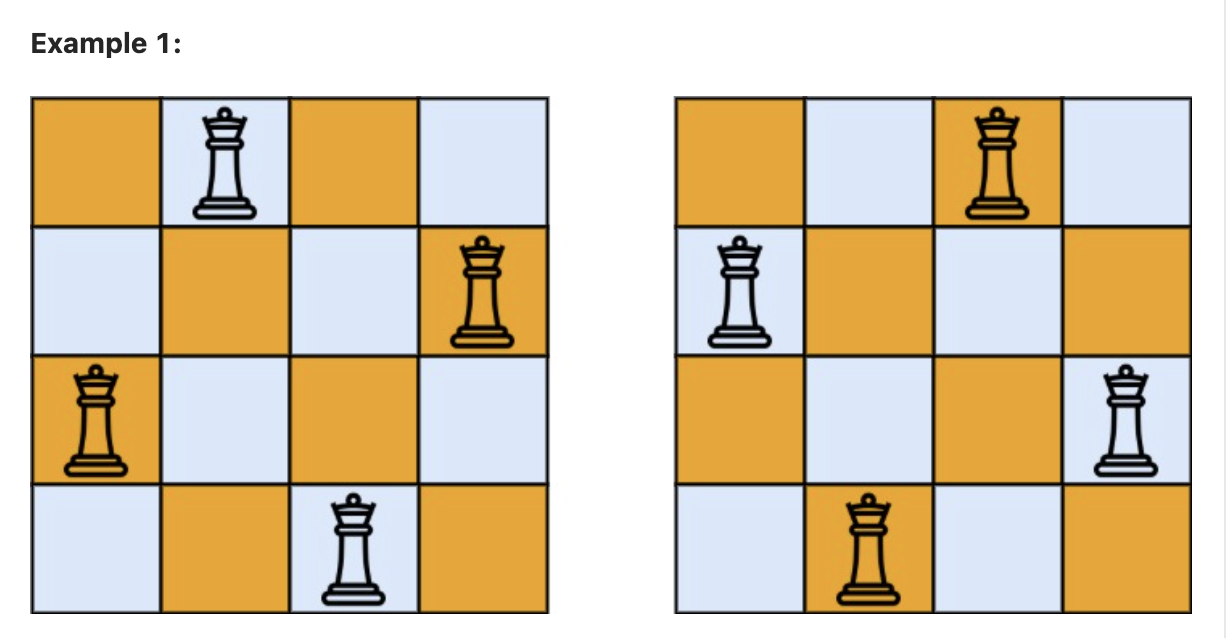

## How a Queen Moves in Chess?

A queen can attack in three directions:

Same Row, Same Column, Diagonals

Example of queen attack directions:

Horizontal  ← →
Vertical    ↑ ↓
Diagonal    ↖ ↗ ↙ ↘

So when placing queens, we must ensure:

- No two queens share the same row

- No two queens share the same column

- No two queens share the same diagonal


e.g. for N = 4

A valid solution for 4-Queens:

. Q . .
. . . Q
Q . . .
. . Q .

Here:

Q = Queen, . = Empty space

No queen attacks another.

## Intuition (How to place the queens?)

Instead of placing queens anywhere, we follow this strategy:

Place one queen per row.

Why?

Because that automatically avoids row conflicts.

Now we only need to check:

1. column conflicts

2. diagonal conflicts

## Step-by-Step Thinking

For N = 4

Start with row 0.

Try placing queen in each column:

Row 0 → Column 0

Board becomes:

Q . . .
. . . .
. . . .
. . . .

Now move to Row 1

Try columns again:

Column 0 ❌ (same column)
Column 1 ❌ (diagonal attack)
Column 2 ✔

Place queen.

Continue for next rows.

If no column works → backtrack.

Remove previous queen and try another column.

## Backtracking Strategy

General approach:

Place queen in row
    if safe
        move to next row
    else
        try next column

if stuck
    remove previous queen
## Algorithm

Step 1 Start

Step 2 Create an empty chessboard

Step 3 Start from row 0

Step 4 For each column in that row
  Check if placing queen is safe

Step 5 If safe
  Place queen

Step 6 Recursively place queen in next row

Step 7 If solution found → print board

Step 8 If stuck → remove previous queen (backtrack)

Step 9 End

## Pseudocode
solve(row):

    if row == n
        print solution
        return

    for each column in board

        if position is safe

            place queen

            solve(row + 1)

            remove queen

Important step:

remove queen

This is the backtracking step.

In [ ]:
for i in range(4):
    print(i)

0
1
2
3


In [2]:
def is_safe(board, row, col, n):

    # Check column
    for i in range(row):
        if board[i][col] == 1:
            return False

    # Check left diagonal
    i = row - 1
    j = col - 1
    while i >= 0 and j >= 0:
        if board[i][j] == 1:
            return False
        i -= 1
        j -= 1

    # Check right diagonal
    i = row - 1
    j = col + 1
    while i >= 0 and j < n:
        if board[i][j] == 1:
            return False
        i -= 1
        j += 1

    return True


def solve_n_queens(board, row, n):

    if row == n:
        print_solution(board, n)
        return

    for col in range(n):

        if is_safe(board, row, col, n):

            board[row][col] = 1

            solve_n_queens(board, row + 1, n)

            board[row][col] = 0   # backtrack


def print_solution(board, n):

    for i in range(n):
        for j in range(n):
            if board[i][j] == 1:
                print("Q", end=" ")
            else:
                print(".", end=" ")
        print()

    print()


n = 4
board = [[0]*n for i in range(n)]

solve_n_queens(board, 0, n)

. Q . . 
. . . Q 
Q . . . 
. . Q . 

. . Q . 
Q . . . 
. . . Q 
. Q . . 



In [3]:
board

[[0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]]

In [1]:
board = ['.' * 4 for i in range(4)]
board

['....', '....', '....', '....']

# **Tower of Hanoi:**

## Intuition (Most Important Part)

Let’s say we want to move 3 disks from A → C.

Step 1: Move top 2 disks from A → B

Step 2: Move largest disk from A → C

Step 3: Move 2 disks from B → C

So the strategy becomes:

Move (n-1) disks -> Move largest disk -> Move (n-1) disks again

This is the core recursive idea.

## Recursive Thinking: General case for n disks:

Move n−1 disks from Source → Helper

Move nth disk from Source → Destination

Move n−1 disks from Helper → Destination

## Base Condition

If only 1 disk remains, we simply move it.

Move disk from A → C

This stops recursion.

## Algorithm

Step 1 Start

Step 2 If n = 1
  Move disk from Source → Destination

Step 3 Move n−1 disks from Source → Helper

Step 4 Move nth disk from Source → Destination

Step 5 Move n−1 disks from Helper → Destination

Step 6 End

## Pseudocode
TowerOfHanoi(n, source, helper, destination)

    if n == 1
        print "Move disk 1 from source to destination"
        return

    TowerOfHanoi(n-1, source, destination, helper)

    print "Move disk n from source to destination"

    TowerOfHanoi(n-1, helper, source, destination)

Notice something important:

In recursion roles of rods change.

# Tower of Hanoi:

## Problem Statement:
You are given three rods:

Source rod (A), Helper rod (B), Destination rod (C)

And N disks of different sizes placed on the source rod in decreasing size order.

You must follow three strict rules:

1️⃣ Only one disk can be moved at a time

2️⃣ Only the top disk can be moved

3️⃣ A larger disk cannot be placed on a smaller disk

- https://www.mathsisfun.com/games/towerofhanoi.html


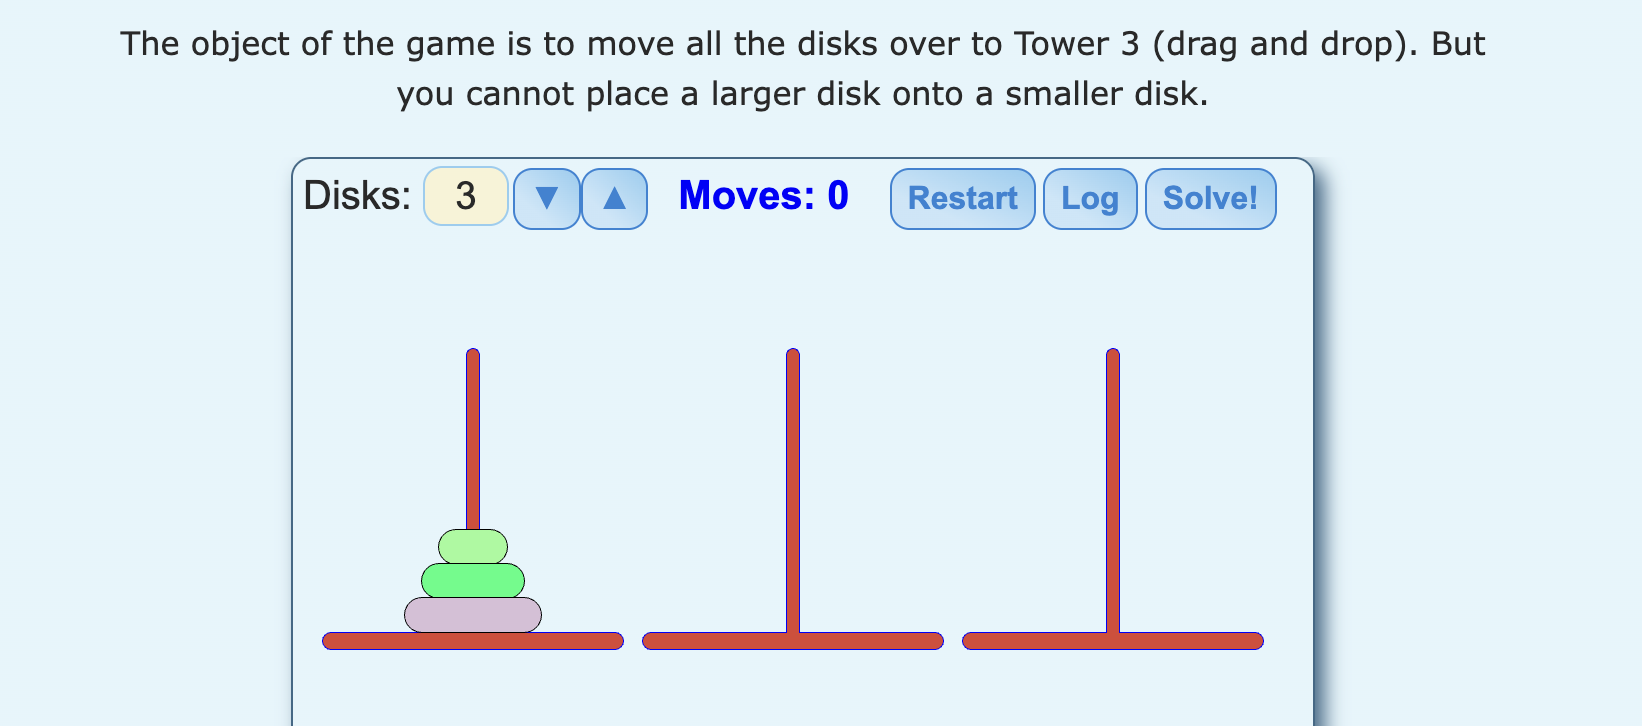

## Steps to follow for 3 disks

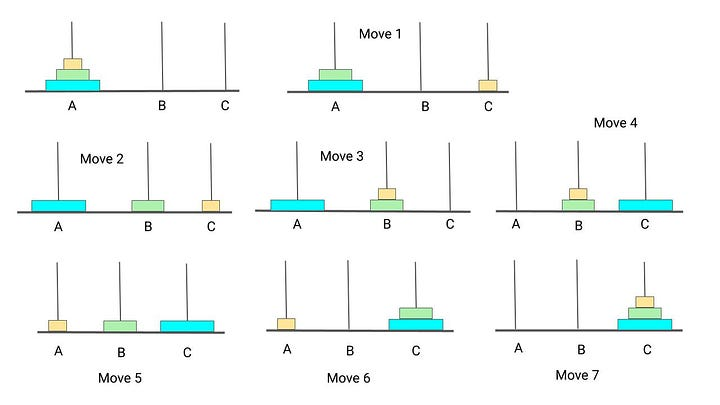

In [ ]:
def tower_of_hanoi(n, source, helper, destination):

    # Base condition
    if n == 1:
        print("Move disk 1 from", source, "to", destination)
        return

    # Step 1: move n-1 disks to helper
    tower_of_hanoi(n-1, source, destination, helper)

    # Step 2: move largest disk
    print("Move disk", n, "from", source, "to", destination)

    # Step 3: move n-1 disks to destination
    tower_of_hanoi(n-1, helper, source, destination)


# Example
tower_of_hanoi(4, "A", "B", "C")

Move disk 1 from A to B
Move disk 2 from A to C
Move disk 1 from B to C
Move disk 3 from A to B
Move disk 1 from C to A
Move disk 2 from C to B
Move disk 1 from A to B
Move disk 4 from A to C
Move disk 1 from B to C
Move disk 2 from B to A
Move disk 1 from C to A
Move disk 3 from B to C
Move disk 1 from A to B
Move disk 2 from A to C
Move disk 1 from B to C


## Minimum moves required: 2^n − 1

## Time Complexity: T(n) = O(2^n)

In [ ]:
import sys

arr = []

for i in range(20):
    arr.append(i)
    print(len(arr), sys.getsizeof(arr))

1 88
2 88
3 88
4 88
5 120
6 120
7 120
8 120
9 184
10 184
11 184
12 184
13 184
14 184
15 184
16 184
17 248
18 248
19 248
20 248
